# ДЗ 4. Задание 3

In [2]:
from Bio import SeqIO
from Bio import motifs
from Bio.Seq import Seq
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
sites = ["GAGGTAAAC", "TCCGTAAGC", "CAGGTTGGA",
"ACAGTCAGC", "TAGGTCAGC", "CAGGTCAGC",
"CAGGTCGAT", "CAGGTCAGC", "CAGGTCAGC",
"CAGGTTGGC"]
ps = [Seq(site) for site in sites]
m = motifs.create(ps)

pfm = m.counts.normalize(pseudocounts=0.1)
background = {'A':0.295,'T':0.295,'G':0.205,'C':0.205}
pwm = pfm.log_odds(background)

In [4]:
L=9
AT_freq=0.295
GC_freq=0.205

def generate(L):
    nucleotides = np.array(['A', 'T', 'G', 'C'])
    p = np.array([0.295, 0.295, 0.205, 0.205])
    indices = np.random.choice(4, size=L, p=p)
    sequence = ''.join(nucleotides[indices])
    return sequence


sequences =[]
scores=[]
for i in range(100000):
    seq = generate(9)
    sequences.append(seq)
    score = 0
    for j, nucleotide in enumerate(seq):
        if nucleotide in pwm:
            score += pwm[nucleotide][j]
    scores.append(score)

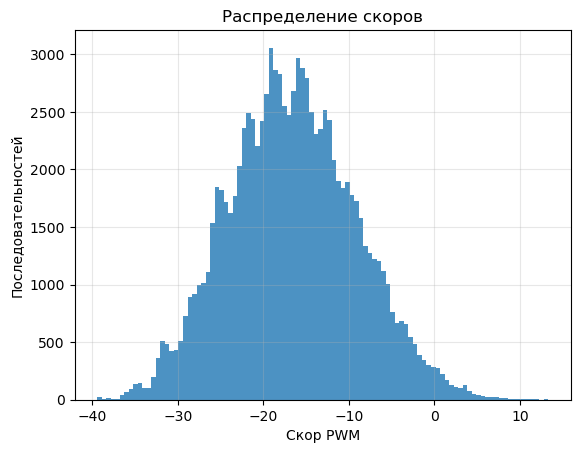

In [10]:
plt.hist(scores, bins=100, alpha=0.8)
plt.xlabel('Скор PWM')
plt.ylabel('Последовательностей')
plt.title('Распределение скоров')
plt.grid(alpha=0.3)
plt.show()

In [14]:
scores = np.array(scores)
def get_pvalue(score):
    return np.mean(scores >= score)

In [40]:
sorted_scores = np.sort(scores)  # по возрастанию
for s in sorted_scores:
    if get_pvalue(s) <= 1e-4:
        threshold = s
        break

print(f"Порог: {threshold:.4f}")
print(f"P-value при пороге: {get_pvalue(threshold):.2e}")

Порог: 10.8497
P-value при пороге: 1.00e-04


еще можно квантилями:

In [45]:
threshold2 = np.quantile(scores, 1 - 1e-4)
print(f"Порог (способ 2): {threshold2:.4f}")
print(f"P-value при пороге: {get_pvalue(threshold2):.2e}")

Порог (способ 2): 10.8484
P-value при пороге: 1.00e-04


значения чуть различаются, тут какие-то приколы с округлением:

In [44]:
for s in sorted_scores[::-1][:15]:
    print(f"score: {s:.4f}, p-value: {get_pvalue(s):.2e}")

score: 13.3210, p-value: 1.00e-05
score: 13.2917, p-value: 2.00e-05
score: 11.9790, p-value: 3.00e-05
score: 11.8986, p-value: 4.00e-05
score: 11.7177, p-value: 5.00e-05
score: 11.3086, p-value: 8.00e-05
score: 11.3086, p-value: 8.00e-05
score: 11.3086, p-value: 8.00e-05
score: 11.2575, p-value: 9.00e-05
score: 10.8497, p-value: 1.00e-04
score: 10.8484, p-value: 1.10e-04
score: 10.3246, p-value: 1.20e-04
score: 10.1793, p-value: 1.30e-04
score: 10.1780, p-value: 1.40e-04
score: 10.0328, p-value: 1.50e-04


In [55]:
threshold2

np.float64(10.848417387994303)

In [57]:
get_pvalue(threshold2)

np.float64(0.0001)

In [62]:
get_pvalue(10.848417) #если округлить

np.float64(0.00011)

вот гистограмма с отсечкой:

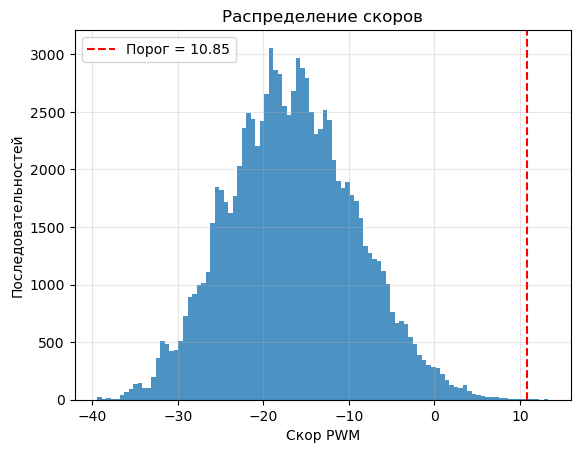

In [66]:
plt.hist(scores, bins=100, alpha=0.8)
plt.axvline(x=threshold, color='red', linestyle='--', label=f'Порог = {threshold:.2f}')

plt.xlabel('Скор PWM')
plt.ylabel('Последовательностей')
plt.title('Распределение скоров')
plt.legend()
plt.grid(alpha=0.3)
plt.show()